In [1]:
import itertools

import numpy as np
import scipy as sp
import networkx as nx
import pandas as pd

import igl

import pyvista as pv
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from src import shapes, vis

# Construct a Complex

In [2]:
def diffeo(vertices, a=0.2, b=1.1, c=0.2, d=1.2, e=0.2, f=0.3):
    v = vertices.copy()
    x, y, z = v[:, 0], v[:, 1], v[:, 2]

    v[:, 0] = x + a*np.sin(b*y) + c*np.sin(d*z)
    v[:, 1] = y + e*np.sin(f*x)

    return v

def cylindrical_twist(vertices, k=0.2, mode="x", scale=0.5):
    """
    Nonlinear cylindrical twist diffeomorphism on R^3.

    vertices: (n,3) array
    mode:
      - "z": angle depends on z  (theta = k * tanh(z/scale))
      - "r": angle depends on radius r (theta = k * tanh(r/scale))
    k: twist strength (radians, roughly bounded by +/-k for tanh)
    scale: controls how quickly tanh saturates
    """
    if mode == 'x':
        v = vertices[:, [1, 2, 0]]
        v = cylindrical_twist(v, k=k, mode="z", scale=scale)
        v = v[:, [2, 0, 1]]
        return v
        
    v = vertices.copy()
    x, y, z = v[:, 0], v[:, 1], v[:, 2]

    r = np.sqrt(x*x + y*y)

    if mode == "z":
        theta = k * np.tanh(z / scale)
    elif mode == "r":
        theta = k * np.tanh(r / scale)
    else:
        raise ValueError('mode must be "z" or "r"')

    c, s = np.cos(theta), np.sin(theta)

    v[:, 0] = c * x - s * y
    v[:, 1] = s * x + c * y
    # z unchanged
    return v

In [3]:
n, m = 17, 16

np.random.seed(42)
vertices0, faces0 = shapes.get_halftori_bouquet(leaves=3, n=n, m=m, l0=1.0, extra_points_on_edge=7, extra_points_on_disk=40, glue=True)
vertices0, faces0 = shapes.split_large_edges(vertices0, faces0, max_length=0.7)

n0, n1 = 24, 24
r0, r1 = 0.8, 1.1
vertices1, faces1 = shapes.get_couple_linked_tori(n0=n0, n1=n1, r0=r0, r1=r1)

vertices0 += np.array([vertices0[:, 0].min(), 0, 0])
vertices1 += np.array([vertices1[:, 0].max(), 0, 0])
vertices1, faces1 = shapes.split_large_edges(vertices1, faces1, max_length=0.8)

vertices, faces, _ = shapes.merge_meshes_with_weld(vertices0, faces0, vertices1, faces1)
#vertices, faces = shapes.split_large_edges(vertices, faces, max_length=0.8)

vertices = cylindrical_twist(vertices, k=-0.6, scale=3.2, mode='x')

In [4]:
mesh = vis.get_pv_mesh(vertices, faces)

pl = pv.Plotter(window_size=(600, 600))
pl.add_mesh(mesh, color='white', smooth_shading=False, show_edges=True, opacity=1.0)
pl.show()

Widget(value='<iframe src="http://localhost:45827/index.html?ui=P_0x72bc7045c290_0&reconnect=auto" class="pyvi…

# Detect a Boundary

In [5]:
def get_boundary_edges(faces):
    """
    """
    face_edges = np.concatenate([faces[:, j] for j in [[0, 1], [0, 2], [1, 2]]])
    face_edges = np.sort(face_edges, axis=1)
    edges = np.unique(face_edges, axis=0)
    edges = edges[(edges[:, None, :] == face_edges).all(axis=-1).sum(axis=-1) != 2]
    return edges


class NonmanifoldBoundaryDetecter:
    def __init__(self, faces, vertices):
        self.faces = np.unique(np.sort(faces, axis=1), axis=0)
        self.vertices = np.array(vertices)

    def get_boundary_edges(self):
        """
        """
        return get_boundary_edges(self.faces)

    def get_conic_vertices(self):
        """
        """
        conic_vertices = []
        for vertex in np.unique(self.faces):
            faces_vertex = faces[(faces == vertex).any(axis=1)]
            connections = faces_vertex[:, None, :, None] == faces_vertex[None, :, None, :]
            connections = connections.any(axis=-1).sum(axis=-1) == 2
            n_components, _ = sp.sparse.csgraph.connected_components(connections, directed=False)
            if n_components > 1:
                conic_vertices.append(vertex)
        conic_vertices = np.array(conic_vertices)
        return conic_vertices

    def get_boundary_graph(self, with_boundary_edges: bool=True, with_conic_vertices: bool=True):
        """
        """
        graph = nx.Graph()
        if with_boundary_edges:
            graph.add_edges_from(self.get_boundary_edges())
        if with_conic_vertices:
            graph.add_nodes_from(self.get_conic_vertices())
        return graph

In [6]:
def best_integer_shape(x, n_max, metric="l2", alphas=2000, refine_steps=25):
    """
    Find integer vector n (same length as x) with 0<=n_i<=n_max
    minimizing distance between x/mean(x) and n/mean(n).

    metric: "l2" or "l1"
    alphas: number of alpha candidates in coarse grid
    refine_steps: local refinement around best alpha
    """
    x = np.asarray(x, dtype=float)
    k = x.size
    if k == 0:
        return np.array([], dtype=int)
    if np.all(x == 0) or np.mean(x) == 0:
        # Degenerate: any n has undefined normalization if mean(n)=0.
        # Return something safe.
        return np.zeros(k, dtype=int)

    # Use nonnegative shape target (common in these problems).
    # If you need signed integers, say so and we can adapt.
    x_pos = np.maximum(x, 0.0)
    x_norm = x_pos / np.mean(x_pos)

    def dist(n):
        m = np.mean(n)
        if m <= 0:
            return np.inf
        n_norm = n / m
        d = x_norm - n_norm
        if metric == "l1":
            return np.sum(np.abs(d))
        return np.sqrt(np.sum(d * d))

    # Coarse alpha range:
    # alpha such that typical rounded values cover [0, n_max]
    # Avoid alpha=0; cap high to allow saturation but not crazy.
    x_mean = np.mean(x_pos)
    x_max = np.max(x_pos)
    alpha_min = 1e-12
    alpha_max = (n_max / (x_mean + 1e-12)) * 4.0  # generous upper bound

    # Coarse grid search
    alpha_grid = np.linspace(alpha_min, alpha_max, alphas)
    best = (np.inf, None, None)

    for a in alpha_grid:
        n = np.rint(a * x_pos).astype(int)
        n = np.clip(n, 0, n_max)
        d = dist(n)
        if d < best[0]:
            best = (d, a, n)

    # Local refinement around best alpha
    best_d, best_a, best_n = best
    a0 = best_a

    # Refine multiplicatively around a0
    for _ in range(refine_steps):
        # try a few nearby candidates
        candidates = a0 * np.array([0.85, 0.92, 0.97, 1.00, 1.03, 1.08, 1.18])
        improved = False
        for a in candidates:
            if a <= 0:
                continue
            n = np.rint(a * x_pos).astype(int)
            n = np.clip(n, 0, n_max)
            d = dist(n)
            if d < best_d:
                best_d, a0, best_n = d, a, n
                improved = True
        if not improved:
            break

    return best_n

In [7]:
def get_chains(graph: nx.Graph, similar_start_end_of_cycle=False):
    """
    Returns the list of all chains of the graph.

    A chain is a maximal path whose internal nodes have degree 2
    (endpoints have degree != 2), or (if a connected component is a
    pure cycle where all nodes have degree 2) the whole cycle as one chain.

    Returns
    -------
    list[list[Hashable]]
        Each chain is returned as an ordered list of nodes.
        For cycle-components, the chain is a cyclic order with the first node
        repeated at the end to make the cycle explicit.
    """
    G = graph

    # Degree in a MultiGraph can be >2 because of parallel edges; this function assumes simple graphs,
    # but we still use G.degree(v) which NetworkX defines for any graph.
    deg = dict(G.degree())

    visited_undirected_edges = set()  # store edges as (min(u,v), max(u,v))

    def mark_edge(u, v):
        a, b = (u, v) if u <= v else (v, u)
        visited_undirected_edges.add((a, b))

    def edge_marked(u, v):
        a, b = (u, v) if u <= v else (v, u)
        return (a, b) in visited_undirected_edges

    chains = []

    # 1) Build chains starting from "junctions" / endpoints: nodes with degree != 2
    for start in G.nodes:
        if deg[start] == 2:
            continue

        for nbr in G.neighbors(start):
            if edge_marked(start, nbr):
                continue

            chain = [start]
            prev = start
            cur = nbr
            mark_edge(prev, cur)

            # Walk forward while we're in degree-2 nodes (internal chain nodes)
            while True:
                chain.append(cur)

                if deg[cur] != 2:
                    # We hit a terminal/junction node: chain ends here.
                    break

                # Choose the next neighbor that isn't the previous node
                nbs = list(G.neighbors(cur))
                # In a simple graph with deg==2, there are exactly 2 neighbors.
                nxt = nbs[0] if nbs[0] != prev else nbs[1]

                if edge_marked(cur, nxt):
                    # We've already consumed this edge; stop to avoid duplicates.
                    break

                prev, cur = cur, nxt
                mark_edge(prev, cur)

            chains.append(chain)

    # 2) Remaining edges (if any) belong to components where all nodes have degree 2 => cycles.
    # We treat each such component as one chain (cycle order).
    for comp in nx.connected_components(G):
        comp_nodes = list(comp)
        if not comp_nodes:
            continue
        if any(deg[v] != 2 for v in comp_nodes):
            continue  # not a pure cycle component

        # If all edges in this component are already visited, skip.
        comp_edges = list(G.subgraph(comp_nodes).edges())
        if all(edge_marked(u, v) for (u, v) in comp_edges):
            continue

        # Build an explicit cyclic order by walking until we return to start.
        start = comp_nodes[0]
        nbrs = list(G.neighbors(start))
        if len(nbrs) != 2:
            # Shouldn't happen in a pure cycle, but be defensive.
            continue

        chain = [start]
        prev = start
        cur = nbrs[0]
        mark_edge(prev, cur)

        while True:
            chain.append(cur)
            if cur == start:
                break

            nbs = list(G.neighbors(cur))
            nxt = nbs[0] if nbs[0] != prev else nbs[1]

            # If we're about to close, allow it; otherwise avoid reusing visited edges.
            if edge_marked(cur, nxt) and nxt != start:
                break

            prev, cur = cur, nxt
            mark_edge(prev, cur)

            if cur == start:
                chain.append(start)
                break

        # Ensure it's a cycle representation: end equals start.
        if chain[-1] != start:
            chain.append(start)

        chains.append(chain)

    if not similar_start_end_of_cycle:
        for i, chain in enumerate(chains):
            if chain[0] == chain[-1]:
                chains[i] = chain[:-1]
    chains = [np.array(chain) for chain in chains]

    return chains

In [42]:
def get_boundary_values(graph, vertices_pos, n_max=3, metric="l2", alphas=2000, refine_steps=25, default_value=1):
    """
    """
    if isinstance(vertices_pos, dict):
        d = len(next(graph.values().__iter__()))
        n = np.max(graph.nodes()).astype(int) + 1
        vertices = np.nan*np.zeros([n, d])
        for node, pos in vertices_pos.items():
            vertices[node] = pos
    else:
        vertices = np.array(vertices_pos)

    chains = get_chains(graph, similar_start_end_of_cycle=True)
    chain_lengths = np.array([np.linalg.norm(vertices[chain[1:]] - vertices[chain[:-1]], axis=-1).sum() for chain in chains])
    chain_lengths_int = best_integer_shape(chain_lengths, n_max=n_max, metric=metric, alphas=alphas, refine_steps=refine_steps)


    node_list = np.array(list(graph.nodes))
    node_to_vertex = -1*np.ones(vertices.shape[0], dtype=int)
    node_to_vertex[node_list] = np.arange(len(node_list))

    vec_val = np.zeros(graph.number_of_nodes()) + default_value
    for i, (chain, length, length_int) in enumerate(zip(chains, chain_lengths, chain_lengths_int)):
        vec_t = np.append(0, np.linalg.norm(vertices[chain][1:] - vertices[chain][:-1], axis=1).cumsum()) / length
        vec_val[node_to_vertex[chain]] = np.cos(2*length_int*np.pi*vec_t)
        
    return vec_val

In [43]:
nmb = NonmanifoldBoundaryDetecter(faces, vertices)
boundary_graph = nmb.get_boundary_graph()
boundary_graph_pos = {node: nmb.vertices[node] for node in boundary_graph.nodes}

boundary_values = get_boundary_values(boundary_graph, vertices)

norm_val = mcolors.TwoSlopeNorm(vmin=boundary_values.min(), vcenter=0, vmax=abs(boundary_values).max())
node_colors_val = [c for c in plt.get_cmap('coolwarm')(norm_val(boundary_values))]


In [44]:
pl = pv.Plotter(window_size=(1000, 600))

pl.add_mesh(mesh, color='white', smooth_shading=False, show_edges=True, opacity=0.3)
vis.add_graph_to_plotter(pl, boundary_graph, boundary_graph_pos, node_color=node_colors_val
                         , edge_color='black', edge_width=2, node_size=10, add_labels=True)

pl.link_views()
pl.show()

Widget(value='<iframe src="http://localhost:45827/index.html?ui=P_0x72bc2a901100_16&reconnect=auto" class="pyv…

# Remashing

For the given manifold $M$ with a boundary $\partial M$ and the function on a boundary $f: \partial M\to \mathbb{R}$  with defined critical points $\text{Crit}(f) = \text{Crit}^\text{min}(f) \cup \text{Crit}^\text{max}(f)$ we aim to extenf $f$ into $\hat{f}: M\to\mathbb{R}$ ($\hat{f}(x) = f(x)\; \forall x\in\partial M$) preserving $f$ integral lines and critical and regular points on a boundary.

Let's do this in a way, that $\text{Crit}^\text{max}(f) \to \text{Crit}^\text{max}(\hat{f})$ and $\text{Crit}^\text{min}(f) \to \text{Crit}^\text{saddle}(\hat{f})$.

Then the mesh on a boundory $\partial M$ require 2 statements:
1. Each face of the mesh should have maximumu one edge from a boundary (or two edges connected by critical point)
2. Each vertex $s\in \text{Crit}^\text{min}(f)$ should have at least one neighbor $v\in M/\partial M$ such that $s$ is the onlye $v$'s neighbor feom the boundary ($\text{Neighbors}(v)\cap\partial M = \{s\}$).


## Flip Ears

We can remesh given triangulation, removing ears, and get the mesh, satisfying the 1st statement.

In [51]:
def flip_ears(faces):
    """
    """
    ears, ear_opp = igl.ears(faces)

    mask = ear_opp.reshape(-1, 1) != np.arange(3)
    edges_to_flip = faces[ears][mask].reshape(-1, 2)

    faces_contains_fliping_edges = (faces[:, np.array(list(itertools.combinations(range(3), 2)))][..., None, :] == edges_to_flip).all(axis=-1).any(axis=-2)
    assert (faces_contains_fliping_edges.sum(axis=0) == 2).all()
    _face_idx, _edge_idx = np.where(faces_contains_fliping_edges)
    faces_fliping_edges = _face_idx.reshape(-1, 2)
    faces_contains_fliping_edges = faces_contains_fliping_edges.any(axis=1)

    opposite_vertives = faces[faces_fliping_edges].reshape(-1, 6)
    mask = (opposite_vertives[:, None, :] != edges_to_flip[:, :, None]).all(axis=-2)
    opposite_vertives = opposite_vertives[mask].reshape(-1, 2)
    
    new_faces = np.vstack([np.hstack([opposite_vertives, edges_to_flip[:, i].reshape(-1, 1)]) for i in range(2)])
    new_faces = np.vstack([faces[~faces_contains_fliping_edges], new_faces])
    new_faces = np.sort(new_faces, axis=1)
    
    return new_faces

In [52]:
test_faces = np.array([[0, 1, 3], [1, 3, 4], [1, 2, 4], [2, 4, 5], 
                       [3, 4, 6], [4, 6, 7], [4, 5, 7], [5, 8, 7]])


print(f'test_faces.shape = {test_faces.shape}')
test_faces

test_faces.shape = (8, 3)


array([[0, 1, 3],
       [1, 3, 4],
       [1, 2, 4],
       [2, 4, 5],
       [3, 4, 6],
       [4, 6, 7],
       [4, 5, 7],
       [5, 8, 7]])

In [53]:
fliped_faces = flip_ears(test_faces)
print(f'fliped_faces.shape = {fliped_faces.shape}')

fliped_faces

fliped_faces.shape = (8, 3)


array([[1, 2, 4],
       [2, 4, 5],
       [3, 4, 6],
       [4, 6, 7],
       [0, 1, 4],
       [4, 5, 8],
       [0, 3, 4],
       [4, 7, 8]])

## Surrounding Saddles Area 

In [47]:
from src.shapes import split_edge

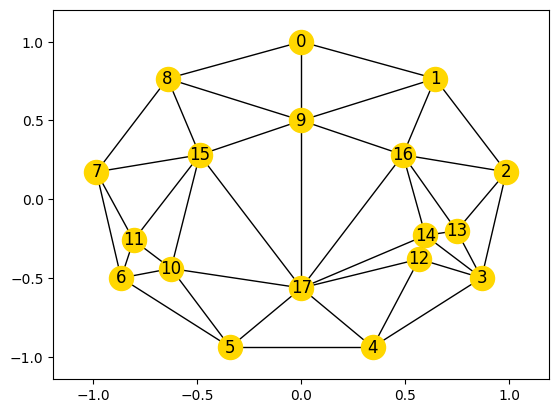

In [48]:
boundary = np.linspace(0, 2*np.pi, 10)[:-1]
boundary = np.transpose([np.sin(boundary), np.cos(boundary)])

saddle0_surrounding = [[0, 0.5]]
saddle1_surrounding = boundary[6] + 0.3*np.array([[0.8, 0.2], [0.2, 0.8]])
saddle2_surrounding = boundary[3] + 0.3*np.array([[-1.0, 0.4], [-0.4, 1.0], [-0.9, 0.9]])

regular_points = [0.6*boundary[edge].mean(axis=0) for edge in [[7, 8], [1, 2], [4, 5]]]


test_vertices = np.vstack([boundary, 
                           saddle0_surrounding, 
                           saddle1_surrounding, 
                           saddle2_surrounding, 
                           regular_points
                           ])

test_faces = sp.spatial.Delaunay(test_vertices).simplices
test_faces = np.sort(test_faces, axis=1)
test_faces = test_faces[(test_faces[:, None, :] != np.array([[3, 12, 13], [12, 13, 14]])).all(axis=1).any(axis=1)]
test_faces = np.vstack([test_faces, [[3, 12, 14], [3, 13, 14]]])


test_graph = nx.Graph()
test_graph.add_nodes_from(range(test_vertices.shape[0]))
for i in itertools.combinations(range(3), 2):
    test_graph.add_edges_from(test_faces[:, list(i)])

nx.draw_networkx(test_graph, pos=test_vertices, hide_ticks=False, node_color='gold')
plt.grid(False)
plt.show()


In [49]:
def split_edges_arroud_saddles(vertices, faces, saddles, edge_choice_strategy='longest'):
    """
    """
    bnd_edges, bnd_face_indices, bnd_local_edge_indices = igl.boundary_facets(test_faces)
    assert np.isin(saddles, np.unique(bnd_edges)).all()
    bnd_vertices = np.unique(bnd_edges)

    bnd_vertices_nonsaddles = bnd_vertices[~np.isin(bnd_vertices, saddles)]

    adj_full = igl.adjacency_matrix(faces)
    
    saddle_neighbors = np.argwhere(adj_full[saddles])
    saddle_neighbor_is_far_from_boundary = (adj_full[:, bnd_vertices_nonsaddles][saddle_neighbors[:, 1]].toarray() == 0).all(axis=1)

    good_saddles = saddles[saddle_neighbors[:, 0][saddle_neighbor_is_far_from_boundary]]
    

    if set(good_saddles) == set(saddles):
        return vertices, faces
    
    if isinstance(edge_choice_strategy, str):
        if edge_choice_strategy == 'longest':
            f_edge_choice_strategy = lambda edges: np.linalg.norm(vertices[edges[:, 0]] - vertices[edges[:, 1]], axis=1).argmax()
        if edge_choice_strategy == 'shortest':
            f_edge_choice_strategy = lambda edges: np.linalg.norm(vertices[edges[:, 0]] - vertices[edges[:, 1]], axis=1).argmin()
    else:
        f_edge_choice_strategy = edge_choice_strategy

    saddles_to_split_arround = saddles[~np.isin(saddles, good_saddles)]

    new_vertices, new_faces = vertices.copy(), faces.copy()
    for saddle in saddles_to_split_arround:
        saddle_faces = faces[(faces == saddle).any(axis=1)]
        mask = saddle_faces != saddle
        saddle_edges = saddle_faces[mask].reshape(-1, 2)

        e0, e1 = saddle_edges[f_edge_choice_strategy(saddle_edges)]
        new_vertices, new_faces = split_edge(new_vertices, new_faces, e0, e1)
    return split_edges_arroud_saddles(new_vertices, new_faces, saddles, edge_choice_strategy=edge_choice_strategy)

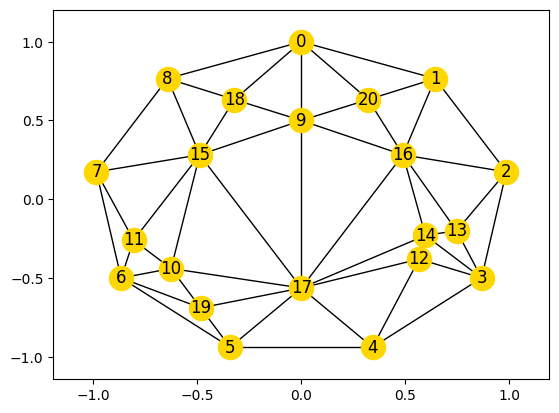

In [50]:
new_vertices, new_faces = split_edges_arroud_saddles(test_vertices, test_faces, np.array([0, 3, 6]))#.toarray()


new_graph = nx.Graph()
new_graph.add_nodes_from(range(new_vertices.shape[0]))
for i in itertools.combinations(range(3), 2):
    new_graph.add_edges_from(new_faces[:, list(i)])

nx.draw_networkx(new_graph, pos=new_vertices, hide_ticks=False, node_color='gold')
plt.grid(False)
plt.show()


# Boundary Inequality System Solution

## Detect critical points on the boundary

In [ ]:
def detect_mins(faces, bnd_indices, bnd_vals):
    faces = np.asarray(faces)
    bnd_indices = np.asarray(bnd_indices)
    bnd_vals = np.asarray(bnd_vals)

    if len(bnd_indices) != len(bnd_vals):
        raise ValueError("bnd_indices and bnd_vals must have same length (aligned case).")

    idx = {int(v): i for i, v in enumerate(bnd_indices)}  # global -> local

    G = nx.Graph()
    G.add_edges_from(faces[:, [0, 1]])
    G.add_edges_from(faces[:, [0, 2]])
    G.add_edges_from(faces[:, [1, 2]])
    H = G.subgraph(bnd_indices)

    mins = []
    for v in bnd_indices:
        v = int(v)
        nbs = [u for u in H.neighbors(v) if int(u) in idx]
        if len(nbs) != 2:
            continue
        vloc = idx[v]
        nloc = [idx[int(u)] for u in nbs]
        if (bnd_vals[nloc] > bnd_vals[vloc]).all():
            mins.append(v)

    return np.array(mins, dtype=bnd_indices.dtype)

def detect_maxs(faces, bnd_indices, bnd_vals):
    return detect_mins(faces, bnd_indices, -bnd_vals)

## Preparing an Example

In [87]:
np.random.seed(0)

test_vertices = np.random.random([64, 2])
test_faces = sp.spatial.Delaunay(test_vertices).simplices

test_nmb = NonmanifoldBoundaryDetecter(test_faces, test_vertices)
test_boundary_graph = test_nmb.get_boundary_graph()
boundary_graph_pos = {node: test_nmb.vertices[node] for node in test_boundary_graph.nodes}

test_nmb